# Python Notebook to Shift, Scale and Combine images

In [10]:
# importing all the relevant libraries 
import numpy as np
import astroalign as aa
import matplotlib.pyplot as plt
import ccdproc
import os
import astropy.io.fits as fits
from ccdproc import CCDData, combiner
from astropy import units as u
from astropy.time import Time
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry
from photutils.detection import DAOStarFinder
from photutils.background import Background2D
from photutils.segmentation  import detect_sources, deblend_sources, SourceCatalog
from scipy.ndimage import shift
import gc
gc.enable()

In [2]:
# ignoring warnings
import warnings
warnings.filterwarnings("ignore")

### Ensure the folders are setup correctly 
##### Create a Folder named "NGC_2547_sub"
##### Then inside that new folder, make three new folder named "b", "g", "r"

#### Input variables, select the star positions for each band

In [3]:
# positions of bright unsaturated stars
#                 star1x,star1y, star2x, star2y, star3x, star3y
positions_all = [[(603.44,1027), (807,863.08), (499.24, 855.88)], # b band positions
                 [(419, 811), (704, 871), (716, 1018)], # g band positions
                 [(418.6,807.4), (553, 1209.4), (704.2, 871)]  # r band positions
                 ]   

# selected appertures for each band
apertures_all = [15.0 , 10.0, 15.0]

# reference images for automatic alignment and scaling - need to justify these 
aa_refidk = [0, 0, 0]

## Python Functions

### Band Selector Variable Assignments

In [4]:
def band_sel(fidx):
    # Band Variables
    bands = ["b", "g", "r"]

    band = bands[fidx]
    fn_name = '*_'+band + '.fit'
    refidx = aa_refidk[fidx]
    return fn_name, refidx, band

# Added in 8 May ------------

## Non Uniform Background Subtraction

In [6]:
# Testing on b-band images - loading in b images
fidx = 1
fn_name, refidx, band = band_sel(fidx)
images = ccdproc.ImageFileCollection("NGC_2547_sub/", glob_include=fn_name)
scim = []
os.chdir("NGC_2547_sub/")
for fn in images.files_filtered():
    scim.append(CCDData.read(fn, unit = "adu")) 

    # Update scim with the correct time meta data
    times = scim[-1].header['DATE-OBS']                                      # Get the time
    t = Time(times, format='isot', scale='utc')                              # Read the time from UTC format
    scim[-1].header['MJD-OBS'] = (float(t.mjd), 'MJD')
os.chdir("../")

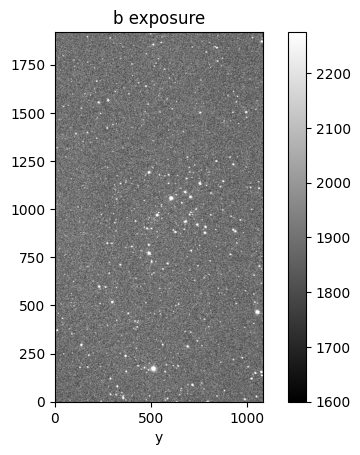

[[1882.98520061 1882.98969395 1882.99868063 ... 1888.12927676
  1888.14446271 1888.15895839]
 [1882.98441514 1882.98890701 1882.99789075 ... 1888.12896089
  1888.14413453 1888.15861846]
 [1882.98284421 1882.98733314 1882.996311   ... 1888.12832915
  1888.14347817 1888.1579386 ]
 ...
 [1896.94008297 1896.94010693 1896.94015485 ... 1880.97274285
  1880.95925805 1880.94638619]
 [1896.94842226 1896.94844306 1896.94848466 ... 1880.9722641
  1880.95907666 1880.94648864]
 [1896.95671502 1896.95673263 1896.95676786 ... 1880.97178492
  1880.95889107 1880.94658331]] adu
1895.0 adu


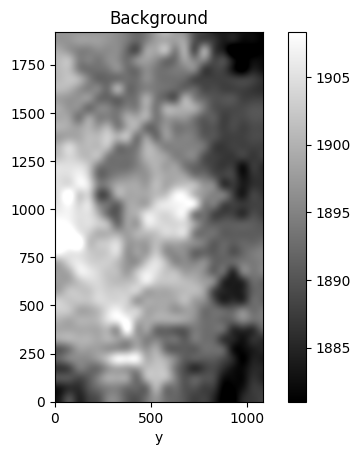

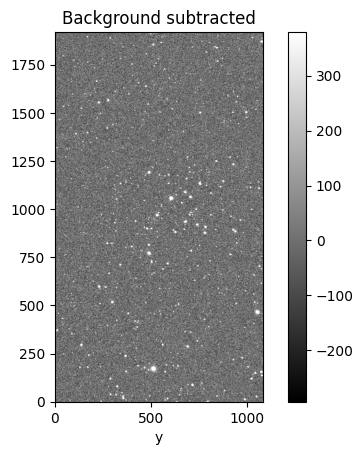

In [15]:
# Plot a single b-band exposures
img_no = 100
vmin=np.nanpercentile(scim[img_no], 1)
vmax=np.nanpercentile(scim[img_no], 99)

plt.imshow(scim[img_no], vmin=vmin, vmax=vmax, origin='lower', cmap='gray')
plt.title('b exposure')
plt.xlabel('x')
plt.xlabel('y')
plt.colorbar(shrink=1.0)
plt.show()

# Model the data using a 50x50 box size for smoothing 
im_bkg = Background2D(scim[img_no], 50)
# Background
print(im_bkg.background)
print(im_bkg.background_median)

# Plot the background - Note the scale
vmin=np.nanpercentile(im_bkg.background.value, 1)
vmax=np.nanpercentile(im_bkg.background.value, 99)
plt.imshow(im_bkg.background.value, vmin=vmin, vmax=vmax, origin='lower', cmap='gray')
plt.title('Background')
plt.xlabel('x')
plt.xlabel('y')
plt.colorbar(shrink=1.0)
plt.show()


# Subtract the background and plot 
testim = scim[img_no].data - im_bkg.background.value

# Background subtracted 
vmin=np.nanpercentile(testim, 1)
vmax=np.nanpercentile(testim, 99)
plt.imshow(testim, vmin=vmin, vmax=vmax, origin='lower', cmap='gray')
plt.title('Background subtracted')
plt.xlabel('x')
plt.xlabel('y')
plt.colorbar(shrink=1.0)
plt.show()

In [25]:
# Finding which images should be excluded due to large background median
bkg_meds = []
for idk, thisimage in enumerate(scim):
    # Model the data using a 50x50 box size for smoothing 
    im_bkg = Background2D(scim[idk], 50)
    # Background
    bkg_meds = np.append(bkg_meds, im_bkg.background_median.value)

print(bkg_meds)

[3820.  2436.  2423.  2406.  2386.  2370.  2337.  2320.  2309.  2295.
 2278.  2256.  2248.  2237.  2228.  2223.  2192.  2182.  2173.  2163.
 2158.  2149.  2137.  2128.  2122.  2117.  2107.  2105.  2099.  2094.
 2090.  2083.  2079.  2076.  2071.  2066.  2055.  2047.  2041.  2038.
 2035.  2031.  2022.  2022.  2018.  2017.  2017.  2004.  1997.  1995.
 1995.  1994.  1989.  1972.  1972.  1967.  1964.  1963.  1955.  1951.
 1946.  1946.  1944.  1942.  1942.  1935.  1934.  1933.  1933.  1933.
 1927.  1927.  1926.  1928.  1929.  1924.  1922.  1917.  1918.  1917.
 1917.  1917.  1914.  1915.  1916.  1915.  1913.  1910.  1913.  1913.
 1912.  1914.  1909.  1906.  1906.  1906.  1906.  1902.  1897.  1894.
 1895.  1897.  1894.  1895.  1897.  1897.  1896.  1889.  1888.  1889.
 1889.  1889.  1890.  1889.  1885.  1885.  1884.  1884.  1883.  1880.
 1880.  1884.  1881.  1880.  1881.  1879.  1882.  1882.  1881.  1883.
 1881.  1883.  1882.  1881.  1882.  1884.  1885.  1877.  1879.  1879.
 1882.  1886.  1885.

In [27]:
def bkg_subtraction(fidx):
    bkg_meds = []
    for idk, thisimage in enumerate(scim):
        # Model the data using a 50x50 box size for smoothing 
        im_bkg = Background2D(scim[idk], 50)
        # Background updating to array 
        bkg_meds = np.append(bkg_meds, im_bkg.background_median.value)

        # removing background in image
        scim[idk].data = scim[idk].data - im_bkg.background.value


    # plotting background 

    # selecting threshold value to exlude
    med_1sig = np.mean(bkg_meds) + np.std(bkg_meds)

    return med_1sig, scim



### Automatic Alignment

In [ ]:
def autom_align(fidx): 
    med_1sig, scim = bkg_subtraction(fidx)
    
    # Generate data from band of interest
    fn_name, refidx, band = band_sel(fidx)
    print("Beginning Image Alignment for ", band, " images")

    # Collate images into scim and go into image path file
    images = ccdproc.ImageFileCollection("NGC_2547_sub/", glob_include=fn_name)
    os.chdir("NGC_2547_sub/")

    scim = []
    for fn in images.files_filtered():
        scim.append(CCDData.read(fn, unit = "adu")) 

        # Update scim with the correct time meta data
        times = scim[-1].header['DATE-OBS']                                      # Get the time
        t = Time(times, format='isot', scale='utc')                              # Read the time from UTC format
        scim[-1].header['MJD-OBS'] = (float(t.mjd), 'MJD')

    # Generate new file names
    newname = []          
    for fn in images.files_filtered():                                       
        newname.extend(["aa"+fn])                                            
    print("Aligned Image: ", newname, ) 

    # Navigate into band folder
    os.chdir(band + "/")
    for idx, thisimage in enumerate(scim):
        # Define images to be shifted
        # Plus zero is a quirky fix to an endian issue (old school)
        img_ref=scim[refidx].data+0       # Reference image
        img_example=scim[idx].data+0      # Image to be shifted image

        img_aligned, footprint = aa.register(img_example, img_ref, detection_sigma=5.0, min_area=9, fill_value=-99999.99)
        # print('Image alignment determined')

        temp=scim[idx]
        temp.data=img_aligned
        temp.meta = scim[idx].meta

        ## only write if image is not exlucded - add logical statement here!!!!!!!!
        # Write the image to a file using the new name (aa- prefix)
        temp.write(newname[idx], overwrite=True)
    print("Image Alignment Completed")
        

### Combine Function

In [ ]:
def combine(fidx):
    phot_tables = autom_align(fidx)

    # Generate data from band of interest
    fn_name, refidx, band = band_sel(fidx)
    print("Beginning Image Combining for ", band, " images")

    images = ccdproc.ImageFileCollection(".",glob_include = fn_name)          
    scim = [CCDData.read(fn) for fn in images.files_filtered()]                         

    # This code is missing comments. What is it doing?
    for idx, thisimage in enumerate(scim):                                              # iterating through each image        
        m = np.ma.median(phot_tables[refidx]['aperture_sum'] / phot_tables[idx]['aperture_sum'])    # scaling each image with the reference image
        print(m)
        scim[idx] = scim[idx].multiply(m * u.adu)                                       # normalising adu counts with reference image

    os.chdir("..")
    os.chdir("..")
    # Comment on the combine operations, including why minmax_clip_min = -500    
    sci_average = ccdproc.combine(scim, method = 'average',dtype = np.float32,          # mean combining images  
                                minmax_clip = True, minmax_clip_min = -500)           # rejecting any data with -500 adu counts in the average combining
    sci_average.write(band+"_NGC_2547_av.fits", overwrite=True)

    sci_median = ccdproc.combine(scim, method = 'median',dtype = np.float32,            # median combining images
                                minmax_clip = True, minmax_clip_min = -500)
    sci_median.write(band+"_NGC_2547_med.fits", overwrite=True)

    del(scim)
    collected = gc.collect()
    print('Check garbage collection', collected)

    print(band, " Images Combining Finished")

## Executing Code
This executions completes shifting, scaling and combining for all bands. 

In [ ]:
for fidx in list(range(3)):
    combine(fidx)